Modified from "Using Deep Learning for Flexible and Scalable Earthquake Forecasting"  
Reference: [Zenodo](https://zenodo.org/records/8161777)

In [1]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import src  
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import functools
import os
import importlib
sys.path.append(str(Path.cwd().parent))
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
set_seed(0) 

In [2]:
checkpoint_dir = Path("../checkpoints/rtpp_20251127-171821") 
# checkpoints/mixer_tpp_20250912-125450
 # "../checkpoints/mixer_tpp_20250907-112659"
 # /checkpoints/mixer_tpp_20250825-114639 /checkpoints/rtpp_20250824-214315
 # checkpoints/mixer_tpp_20250819-143535 checkpoints/mixer_tpp_20250819-143210
#  checkpoints/rtpp_20250819-142340
checkpoint_path = checkpoint_dir / "best_model_1.pth"

## Loading a trained model

In [3]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint,load_model_from_checkpoint

check_point = torch.load(checkpoint_path,weights_only=False)    
args = load_args_from_checkpoint(None, check_point)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_builder = ModelBuilder.by_name(args.model.lower())()
model = model_builder(args, device)
model,_,_ = load_model_from_checkpoint(model, check_point)
# model.set_attn_type("flash")
# model.set_attn_dropout(0)
model = torch.compile(model)
model.eval() 

load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'model': 'rtpp', 'num_event_types': 1, 'pad_token_id': 1, 'task_type': 'tpp', 'bg_model': 'proportional', 'bg_model_cfg': {'d_feature': 1}, 'batch_size': 32, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.001, 'weight_decay': 1e-05, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'none', 'step_lr_step_size_ratio': 0.2, 'step_lr_gamma': 0.8, 'rnn_type': 'GRU', 'd_model': 32, 'rnn_dropout': 0.3, 'num_components': 32, 'dim': 1, 'epochs': 500, 'save_dir': 'checkpoints/rtpp_20251127-171821', 'cuda_id': '0', 'dataset': 'PNR', 'seed': 0, 'minibatch_training': True, 'split_by_time': True, 'time_order': ['train', 'val', 'test'], 'cuda': True, 'tau_mean': 0.06001083552837372, 'tau_min': 5.3589729986924795e-08, 'tau_max': 17.831666946411133, 'tau_q05': 0.002222222276031971, 'tau_q025': 1.1896516298293136e-0

OptimizedModule(
  (_orig_mod): RecurrentTPP(
    (hypernet_time): Linear(in_features=32, out_features=96, bias=True)
    (hypernet_mag): Linear(in_features=32, out_features=1, bias=True)
    (rnn): GRU(2, 32, batch_first=True)
    (dropout): Dropout(p=0.3, inplace=False)
    (bg_model): ProportionalBGModel()
  )
)

In [4]:
from torch.nn.functional import softplus
softplus(model.bg_model.raw_weight)

tensor([[1.0880]], device='cuda:0', grad_fn=<SoftplusBackward0>)

## Loading the catalog

In [5]:
# args.dataset = "ChinaArray" 
catalog_ds_class = catalog.Catalog.by_name(f"{args.dataset}-Standard")
catalog_ds = catalog_ds_class(root_dir=f'../data/{args.dataset}/raw',catalog_file=None)

Loading existing catalog from /home/yzzhang/pjt/chuandian_eq/data/PNR/raw.


In [6]:
catalog_ds.full_sequence

Sequence(
  inter_times: [22974],
  arrival_times: [22973],
  t_start: 0.0,
  t_end: 1548.0,
  t_nll_start: 0.0,
  mag: [22973],
  loc: [22973, 2],
  depth: [22973],
  time_series: [92316, 1],
  time_series_times: [92316]
)

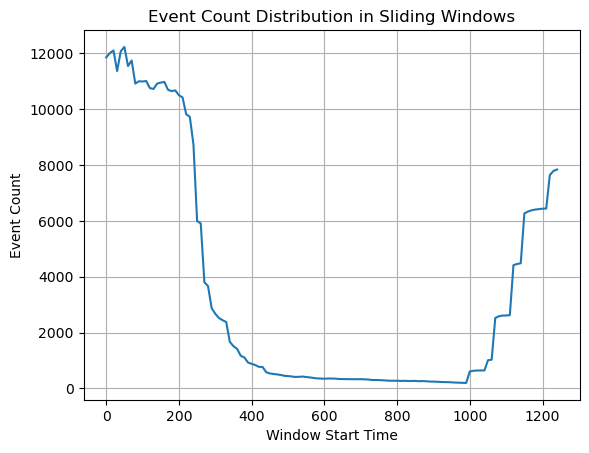

In [7]:
window_size = 300
stride = 10
arrival_times = catalog_ds.full_sequence.arrival_times
max_time = arrival_times.max().item()
window_starts = torch.arange(0, max_time - window_size + stride, stride)
counts = torch.zeros(len(window_starts), dtype=torch.int32)

for i, start in enumerate(window_starts):
    end = start + window_size
    mask = (arrival_times >= start) & (arrival_times < end)
    counts[i] = mask.sum()
plt.plot(window_starts, counts)
plt.xlabel('Window Start Time')
plt.ylabel('Event Count')
plt.title('Event Count Distribution in Sliding Windows')
plt.grid(True)
plt.show()

In [8]:
# b_seq = model.compute_b_value(catalog_ds.full_sequence.to(device),True)
# plt.plot(b_seq.squeeze().detach().cpu().numpy())
# plt.savefig(checkpoint_dir/'b_pred.png')
# data = b_seq.squeeze().detach().cpu().numpy()
# smooth = pd.Series(data).rolling(window=500, min_periods=1).mean()
# plt.plot(smooth)
# plt.savefig(checkpoint_dir/'b_pred_smooth.png')

## Prepare the data

We trained the TPP model using the `train` and `val` sequences. Now we will use the unseen section of the `test` sequence (in orange) to evaluate forecasting performance of the model.

<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

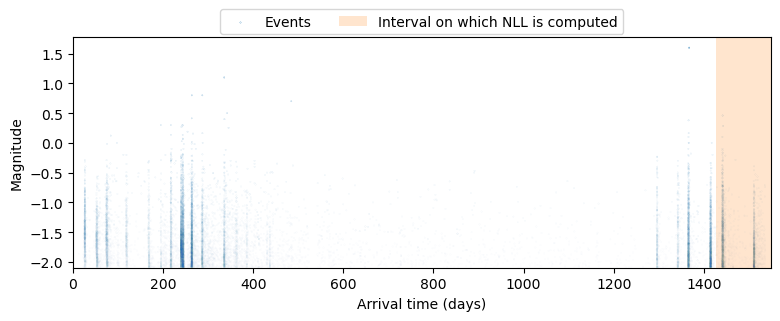

In [9]:
from src.utils.visualization import visualize_sequence
test_seq = catalog_ds.test[0]
train_seq = catalog_ds.train[0]
visualize_sequence(test_seq, show_nll=True)

We would like to generate a 30-day forecast for the interval `[13000, 13030]`. For this, we select two subsequences:
- `past_seq`: Contains events from `[0, 13000]`, is used to condition the model
- `observed_seq`: Contains actually observed events from `[13000, 13030]`.

In [10]:
t_forecast = 1500 # 4000 13000
duration = 10 # 7 30
num_samples = 10000 # 10000

# Past events that we condition on
past_seq = test_seq.get_subsequence(0, t_forecast) #  3500
observed_seq = test_seq.get_subsequence(t_forecast, t_forecast + duration)

## Generate the forecast

In [11]:
past_seq.float()

Sequence(
  inter_times: [21547],
  arrival_times: [21546],
  t_start: 0.0,
  t_end: 1500.0,
  t_nll_start: 1428.0,
  mag: [21546],
  loc: [21546, 2],
  depth: [21546],
  time_series: [90001, 1],
  time_series_times: [90001]
)

In [12]:
past_batch = src.data.Batch.from_list([past_seq])

In [13]:
torch.mean(past_batch.inter_times)

tensor(0.0696)

In [14]:
if torch.cuda.is_available():
    model.to('cuda:0')
    past_seq.to('cuda:0')

In [15]:
# torch.backends.cudnn.enabled = False

In [16]:
model.bg_model.cache_batch(time_series=test_seq.time_series.unsqueeze(0), time_series_times=test_seq.time_series_times.unsqueeze(0))

In [17]:
set_seed(3) 
model.eval()  # Set the model to evaluation mode

all_forecasts = []
samples_per_batch = 10000
for _ in range(num_samples // samples_per_batch):
    # forecast = model.sample_with_cache(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True)
    # forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True, max_sample_len=4000)
    forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True)
    all_forecasts.extend(forecast)

sample_nhpp_inverse: sampled 165 events out of 10000.
total_time: tensor([ 0.8904, 10.0000,  0.1969,  ...,  0.8333,  0.3635,  0.1925],
       device='cuda:0'), min: 4.112720489501953e-05
sample_nhpp_inverse: sampled 47 events out of 10000.
total_time: tensor([ 1.0449, 10.5027,  0.5270,  ...,  0.8629,  0.6981,  0.3928],
       device='cuda:0'), min: 0.0019925832748413086
sample_nhpp_inverse: sampled 82 events out of 10000.
total_time: tensor([ 1.1981, 10.5272,  0.6177,  ...,  1.1459,  1.4199,  0.6427],
       device='cuda:0'), min: 0.005571421235799789
sample_nhpp_inverse: sampled 79 events out of 10000.
total_time: tensor([ 1.7278, 10.8275,  0.7500,  ...,  1.3978,  2.3691,  0.8770],
       device='cuda:0'), min: 0.006145465187728405
sample_nhpp_inverse: sampled 93 events out of 10000.
total_time: tensor([ 1.7497, 10.8908,  1.3946,  ...,  1.6310,  3.5566,  1.0890],
       device='cuda:0'), min: 0.007301970385015011
sample_nhpp_inverse: sampled 82 events out of 10000.
total_time: tensor(

/home/yzzhang/pjt/chuandian_eq/src/models/bg/proportional.py:245: UserWarning: sample_nhpp_inverse: sampled tau exceeds dt by up to 1.073e-05; clamping to dt.
  warnings.warn(f"sample_nhpp_inverse: sampled tau exceeds dt by up to {diff.max().item():.3e}; clamping to dt.")
/home/yzzhang/pjt/chuandian_eq/src/models/bg/proportional.py:245: UserWarning: sample_nhpp_inverse: sampled tau exceeds dt by up to 4.204e-05; clamping to dt.
  warnings.warn(f"sample_nhpp_inverse: sampled tau exceeds dt by up to {diff.max().item():.3e}; clamping to dt.")
/home/yzzhang/pjt/chuandian_eq/src/models/bg/proportional.py:245: UserWarning: sample_nhpp_inverse: sampled tau exceeds dt by up to 5.379e-05; clamping to dt.
  warnings.warn(f"sample_nhpp_inverse: sampled tau exceeds dt by up to {diff.max().item():.3e}; clamping to dt.")
/home/yzzhang/pjt/chuandian_eq/src/models/bg/proportional.py:245: UserWarning: sample_nhpp_inverse: sampled tau exceeds dt by up to 1.445e-05; clamping to dt.
  warnings.warn(f"samp

sample_nhpp_inverse: sampled 1284 events out of 10000.
total_time: tensor([11.3163, 14.3934, 11.8392,  ..., 12.2892, 13.1077, 11.2819],
       device='cuda:0'), min: 0.16327108442783356
sample_nhpp_inverse: sampled 1337 events out of 10000.
total_time: tensor([11.3253, 14.3934, 11.8392,  ..., 12.2974, 13.2262, 11.3962],
       device='cuda:0'), min: 0.1781349778175354
sample_nhpp_inverse: sampled 1302 events out of 10000.
total_time: tensor([11.6876, 14.3960, 11.8562,  ..., 12.8711, 13.2342, 11.4400],
       device='cuda:0'), min: 0.18967410922050476
sample_nhpp_inverse: sampled 1233 events out of 10000.
total_time: tensor([11.7515, 14.3982, 11.8563,  ..., 12.9602, 13.2938, 11.4671],
       device='cuda:0'), min: 0.18979328870773315
sample_nhpp_inverse: sampled 1201 events out of 10000.
total_time: tensor([11.9134, 14.3982, 12.1810,  ..., 13.0585, 13.3547, 11.4862],
       device='cuda:0'), min: 0.1898379623889923
sample_nhpp_inverse: sampled 1126 events out of 10000.
total_time: tenso

/home/yzzhang/pjt/chuandian_eq/src/models/bg/proportional.py:245: UserWarning: sample_nhpp_inverse: sampled tau exceeds dt by up to 4.749e-05; clamping to dt.
  warnings.warn(f"sample_nhpp_inverse: sampled tau exceeds dt by up to {diff.max().item():.3e}; clamping to dt.")
/home/yzzhang/pjt/chuandian_eq/src/models/bg/proportional.py:245: UserWarning: sample_nhpp_inverse: sampled tau exceeds dt by up to 1.418e-05; clamping to dt.
  warnings.warn(f"sample_nhpp_inverse: sampled tau exceeds dt by up to {diff.max().item():.3e}; clamping to dt.")
/home/yzzhang/pjt/chuandian_eq/src/models/bg/proportional.py:245: UserWarning: sample_nhpp_inverse: sampled tau exceeds dt by up to 1.934e-06; clamping to dt.
  warnings.warn(f"sample_nhpp_inverse: sampled tau exceeds dt by up to {diff.max().item():.3e}; clamping to dt.")
/home/yzzhang/pjt/chuandian_eq/src/models/bg/proportional.py:245: UserWarning: sample_nhpp_inverse: sampled tau exceeds dt by up to 2.062e-05; clamping to dt.
  warnings.warn(f"samp

sample_nhpp_inverse: sampled 500 events out of 10000.
total_time: tensor([15.5837, 14.5265, 14.5499,  ..., 13.1842, 16.2268, 12.9728],
       device='cuda:0'), min: 0.27792978286743164
sample_nhpp_inverse: sampled 512 events out of 10000.
total_time: tensor([15.7103, 14.5286, 14.5760,  ..., 13.2208, 16.7194, 12.9780],
       device='cuda:0'), min: 0.28380101919174194
sample_nhpp_inverse: sampled 472 events out of 10000.
total_time: tensor([15.8446, 14.5287, 14.6475,  ..., 13.2218, 17.0541, 13.0455],
       device='cuda:0'), min: 0.3060480058193207
sample_nhpp_inverse: sampled 429 events out of 10000.
total_time: tensor([15.8481, 14.5287, 14.6711,  ..., 13.2256, 17.2981, 13.1845],
       device='cuda:0'), min: 0.30821946263313293
sample_nhpp_inverse: sampled 437 events out of 10000.
total_time: tensor([15.9724, 14.5303, 14.8988,  ..., 13.2423, 17.3546, 13.4716],
       device='cuda:0'), min: 0.3083171844482422
sample_nhpp_inverse: sampled 408 events out of 10000.
total_time: tensor([16.

...

/home/yzzhang/pjt/chuandian_eq/src/models/bg/proportional.py:245: UserWarning: sample_nhpp_inverse: sampled tau exceeds dt by up to 3.591e-05; clamping to dt.
  warnings.warn(f"sample_nhpp_inverse: sampled tau exceeds dt by up to {diff.max().item():.3e}; clamping to dt.")
/home/yzzhang/pjt/chuandian_eq/src/models/bg/proportional.py:245: UserWarning: sample_nhpp_inverse: sampled tau exceeds dt by up to 4.966e-06; clamping to dt.
  warnings.warn(f"sample_nhpp_inverse: sampled tau exceeds dt by up to {diff.max().item():.3e}; clamping to dt.")


sample_nhpp_inverse: sampled 18 events out of 10000.
total_time: tensor([78.1007, 54.9340, 23.2519,  ..., 57.8672, 88.9291, 82.1582],
       device='cuda:0'), min: 1.994064450263977
sample_nhpp_inverse: sampled 29 events out of 10000.
total_time: tensor([78.7970, 55.7089, 23.2856,  ..., 58.2060, 88.9827, 82.3679],
       device='cuda:0'), min: 1.9940937757492065
sample_nhpp_inverse: sampled 18 events out of 10000.
total_time: tensor([79.3474, 55.9854, 23.5926,  ..., 58.3869, 89.1471, 82.3797],
       device='cuda:0'), min: 1.994930624961853
sample_nhpp_inverse: sampled 13 events out of 10000.
total_time: tensor([79.7092, 55.9997, 23.6149,  ..., 58.7620, 89.1642, 82.4607],
       device='cuda:0'), min: 1.995568871498108
sample_nhpp_inverse: sampled 19 events out of 10000.
total_time: tensor([82.2147, 56.3067, 23.6880,  ..., 58.8595, 89.3955, 82.6271],
       device='cuda:0'), min: 1.9958863258361816
sample_nhpp_inverse: sampled 12 events out of 10000.
total_time: tensor([82.5724, 56.306

/home/yzzhang/pjt/chuandian_eq/src/models/bg/proportional.py:245: UserWarning: sample_nhpp_inverse: sampled tau exceeds dt by up to 1.558e-05; clamping to dt.
  warnings.warn(f"sample_nhpp_inverse: sampled tau exceeds dt by up to {diff.max().item():.3e}; clamping to dt.")


total_time: tensor([90.5805, 61.3482, 25.4392,  ..., 70.0119, 98.0841, 87.8045],
       device='cuda:0'), min: 2.127568006515503
sample_nhpp_inverse: sampled 20 events out of 10000.
total_time: tensor([91.0637, 61.3965, 25.7965,  ..., 70.1101, 98.3262, 88.7045],
       device='cuda:0'), min: 2.1285080909729004
sample_nhpp_inverse: sampled 18 events out of 10000.
total_time: tensor([91.1346, 61.5895, 26.0100,  ..., 70.4142, 99.0071, 88.7652],
       device='cuda:0'), min: 2.1433894634246826
sample_nhpp_inverse: sampled 14 events out of 10000.
total_time: tensor([91.6937, 61.7106, 26.3981,  ..., 70.6817, 99.6470, 88.7712],
       device='cuda:0'), min: 2.1441354751586914
sample_nhpp_inverse: sampled 24 events out of 10000.
total_time: tensor([ 92.3565,  62.4442,  26.6326,  ...,  70.9662, 100.4843,  88.8307],
       device='cuda:0'), min: 2.1447863578796387
sample_nhpp_inverse: sampled 16 events out of 10000.
total_time: tensor([ 92.7091,  62.4991,  26.6406,  ...,  71.1714, 100.6700,  89.

/home/yzzhang/pjt/chuandian_eq/src/data/sequence.py:234: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


In [18]:
all_forecasts

[Sequence(
   inter_times: [39],
   arrival_times: [38],
   t_start: 1500.0,
   t_end: 1510.0,
   t_nll_start: 1500.0,
   mag: [38]
 ),
 Sequence(
   inter_times: [1],
   arrival_times: [0],
   t_start: 1500.0,
   t_end: 1510.0,
   t_nll_start: 1500.0,
   mag: [0]
 ),
 Sequence(
   inter_times: [32],
   arrival_times: [31],
   t_start: 1500.0,
   t_end: 1510.0,
   t_nll_start: 1500.0,
   mag: [31]
 ),
 Sequence(
   inter_times: [50],
   arrival_times: [49],
   t_start: 1500.0,
   t_end: 1510.0,
   t_nll_start: 1500.0,
   mag: [49]
 ),
 Sequence(
   inter_times: [35],
   arrival_times: [34],
   t_start: 1500.0,
   t_end: 1510.0,
   t_nll_start: 1500.0,
   mag: [34]
 ),
 Sequence(
   inter_times: [63],
   arrival_times: [62],
   t_start: 1500.0,
   t_end: 1510.0,
   t_nll_start: 1500.0,
   mag: [62]
 ),
 Sequence(
   inter_times: [47],
   arrival_times: [46],
   t_start: 1500.0,
   t_end: 1510.0,
   t_nll_start: 1500.0,
   mag: [46]
 ),
 Sequence(
   inter_times: [43],
   arrival_times: 

(array([1.377e+03, 4.933e+03, 1.760e+03, 5.310e+02, 3.120e+02, 2.850e+02,
        2.290e+02, 1.620e+02, 1.060e+02, 9.100e+01, 5.100e+01, 4.600e+01,
        3.400e+01, 2.100e+01, 1.100e+01, 1.500e+01, 1.400e+01, 6.000e+00,
        3.000e+00, 4.000e+00, 1.000e+00, 3.000e+00, 3.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([  0. ,  23.1,  46.2,  69.3,  92.4, 115.5, 138.6, 161.7, 184.8,
        207.9, 231. , 254.1, 277.2, 300.3, 323.4, 346.5, 369.6, 392.7,
        415.8, 438.9, 462. , 485.1, 508.2, 531.3, 554.4, 577.5, 600.6,
        623.7, 646.8, 669.9, 693. ]),
 <BarContainer object of 30 artists>)

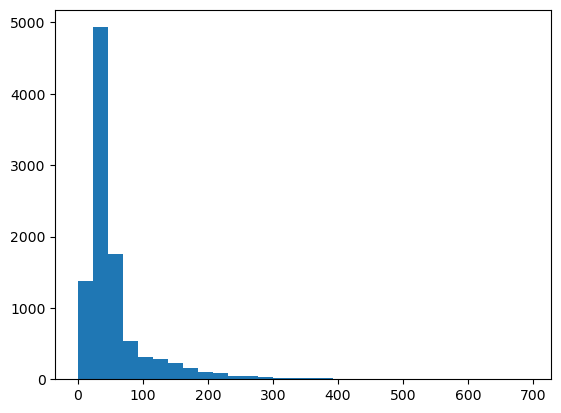

In [19]:
len_list = [len(f.arrival_times) for f in all_forecasts]
plt.hist(len_list, bins=30)

In [20]:
zero_indices = []
for idx, fc in enumerate(all_forecasts):
    t = torch.as_tensor(fc.inter_times).cpu()
    if (t == 0).any():
        zero_indices.append(idx)

if zero_indices:
    print("Found zeros in inter_times at indices:", zero_indices)
else:
    print("No zeros found in inter_times of any forecast.")
print("Number of forecasts with zero inter_times:", len(zero_indices))

Found zeros in inter_times at indices: [3145]
Number of forecasts with zero inter_times: 1


`forecast` is a list, where each element is a `eq.data.Sequence` that represents a possible continuation of the catalog over the interval `[13000, 13030]`.

With the following function, we
- visualize 10 randomly chosen trajectories as a counting process
- plot the distribution of the total # of events in the forecast interval

In [21]:
# importlib.reload(src.utils.visualization)

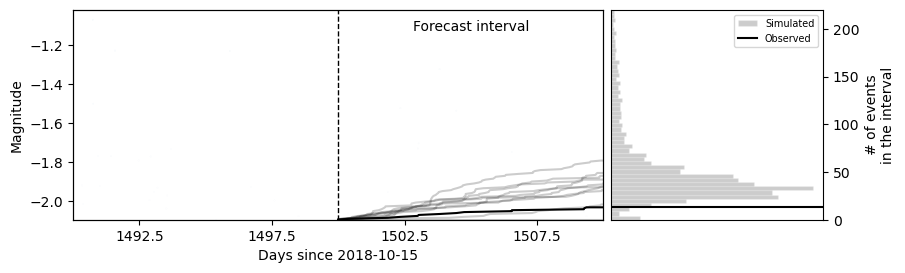

In [22]:
date_str = catalog_ds.metadata['start_ts'].strftime('%Y-%m-%d')
src.utils.visualization.visualize_trajectories(test_seq, all_forecasts,save_path=checkpoint_dir/"all_forecasts.pdf",figsize=(10,3),xlabel='Days since '+date_str)
# src.utils.visualization.visualize_trajectories(train_seq, all_forecasts,save_path=checkpoint_dir/"all_forecasts.png")

In [23]:
import  src.utils.catalog_tests as catalog_tests

In [24]:
test_seq

Sequence(
  inter_times: [22974],
  arrival_times: [22973],
  t_start: 0.0,
  t_end: 1548.0,
  t_nll_start: 1428.0,
  mag: [22973],
  loc: [22973, 2],
  depth: [22973],
  time_series: [92192, 1],
  time_series_times: [92192]
)

N-test

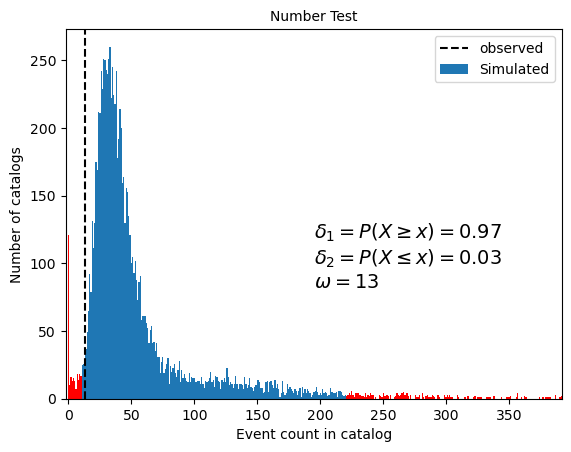

In [25]:
number_test_result = catalog_tests.run_number_test_result(
    event_counts=[len(fc) for fc in all_forecasts],
    obs_count=len(observed_seq),                   
    min_mw=catalog_ds.metadata['mag_completeness'],
    obs_name='observed',
    sim_name='Simulated',
    plot=False
)
ax= number_test_result.plot(plot_args={'figsize':(6.4,4.8),'tight_layout':False})
plt.savefig(checkpoint_dir/'n_test.pdf')

M-test

In [26]:
config_dict = {
    'min_mw': catalog_ds.metadata['mag_completeness'],
    'max_mw': 10,
    'dmw': 0.01
}

magnitude_bins, distribution = catalog_tests.compute_magnitude_distribution(
    forecast[0].mag.cpu().numpy(), 
   **config_dict
)

In [27]:
get_counts = functools.partial(catalog_tests.compute_magnitude_distribution, **config_dict)
result_dict = catalog_tests.magnitude_test_from_counts(
    observed_catalog=observed_seq,
    forecast_catalogs=all_forecasts,
    get_counts=lambda cat: get_counts(np.asarray(cat.mag.cpu())),
    verbose=False
)


IndexError: index -1 is out of bounds for axis 0 with size 0

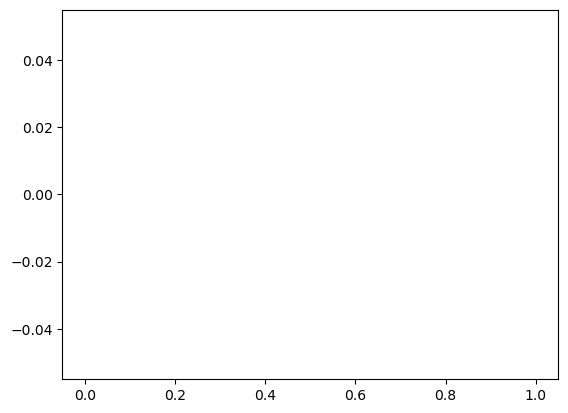

In [28]:
magnitude_test_result = catalog_tests.run_magnitude_test_result(
    result_dict=result_dict,
    obs_catalog_repr='obs',
   obs_name='observed',
    sim_name='Simulated',
    plot=False
)
magnitude_test_result.plot(plot_args={'figsize':(6.4,4.8),'tight_layout':False})
plt.savefig(checkpoint_dir/'m_test.pdf')

In [ ]:
checkpoint_dir

PosixPath('../checkpoints/rtpp_20251125-223019')